# Muhammad Hassan Khalid
# 21L-5692
# BDS-6A

#### Importing the Libraries

In [1]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

#### Load the dataset

In [2]:
df = pd.read_csv("OnlineRetail.csv")

In [3]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [4]:
df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#### Plot Quantity vs. UnitPrice

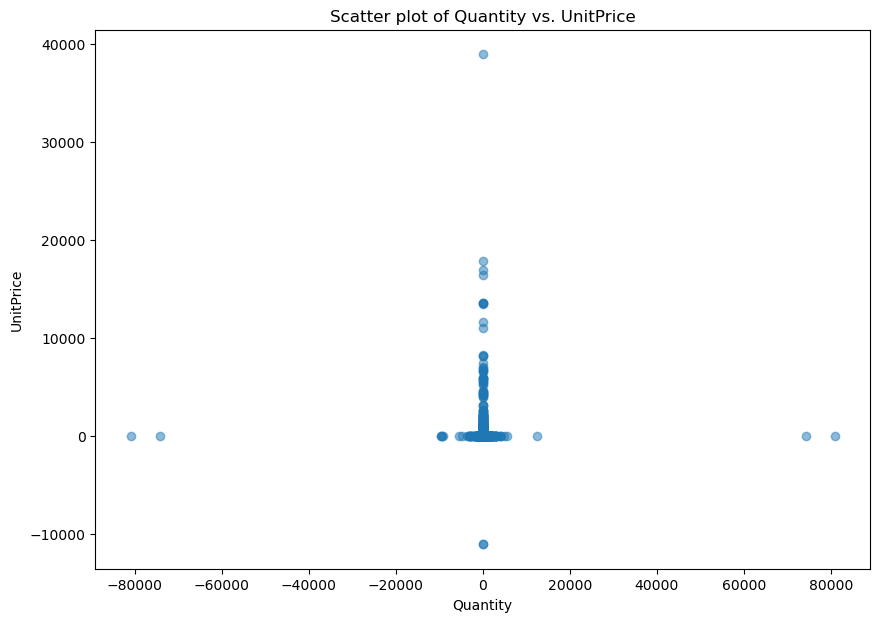

In [5]:
plt.figure(figsize=(10, 7))
plt.scatter(df["Quantity"], df["UnitPrice"], alpha=0.5)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Scatter plot of Quantity vs. UnitPrice")
plt.show()

#### Total number of missing values in the dataset

In [6]:
total_missing_values = df.isnull().sum()
print(total_missing_values)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


#### Preprocess the data

In [7]:
df = df.dropna()  # Drop rows with missing values

#### Total number of missing values in the dataset

In [8]:
total_missing_values = df.isnull().sum()
print(total_missing_values)

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


#### Plot Quantity vs. UnitPrice

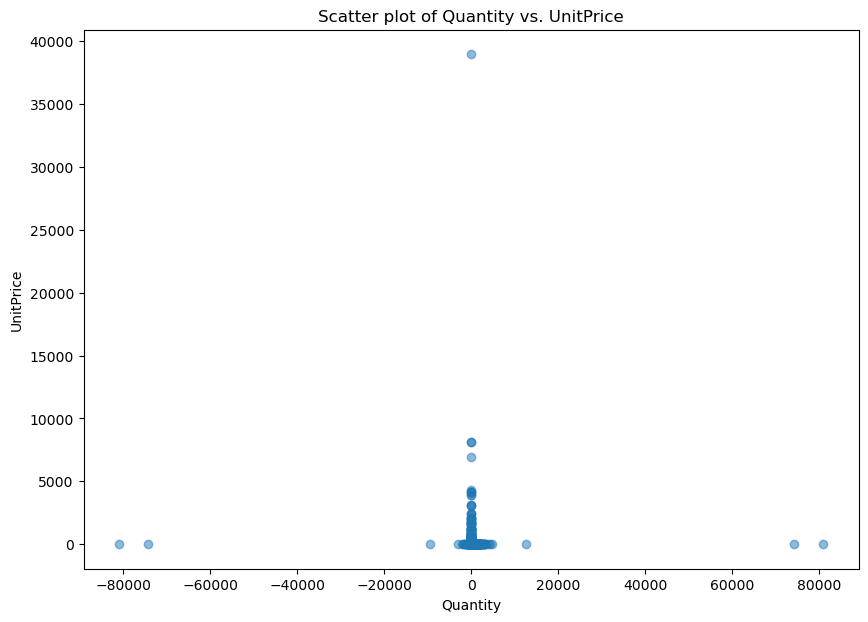

In [9]:
plt.figure(figsize=(10, 7))
plt.scatter(df["Quantity"], df["UnitPrice"], alpha=0.5)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Scatter plot of Quantity vs. UnitPrice")
plt.show()

#### Define the columns to check for outliers

In [10]:
outlier_columns = ["Quantity", "UnitPrice"]

#### Calculate the Interquartile Range (IQR) for each column

In [11]:
Q1 = df[outlier_columns].quantile(0.25)  # First quartile
Q3 = df[outlier_columns].quantile(0.75)  # Third quartile
IQR = Q3 - Q1  # Interquartile Range

#### Define bounds for outliers

In [12]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#### Keep only the rows within the bounds to remove outliers

In [13]:
df_clean = df[
    (df[outlier_columns] >= lower_bound).all(axis=1) &
    (df[outlier_columns] <= upper_bound).all(axis=1)
]

#### Output the number of rows before and after removing outliers

In [14]:
print("Rows before removing outliers:", len(df))
print("Rows after removing outliers:", len(df_clean))

Rows before removing outliers: 406829
Rows after removing outliers: 344393


#### Plot Quantity vs. UnitPrice

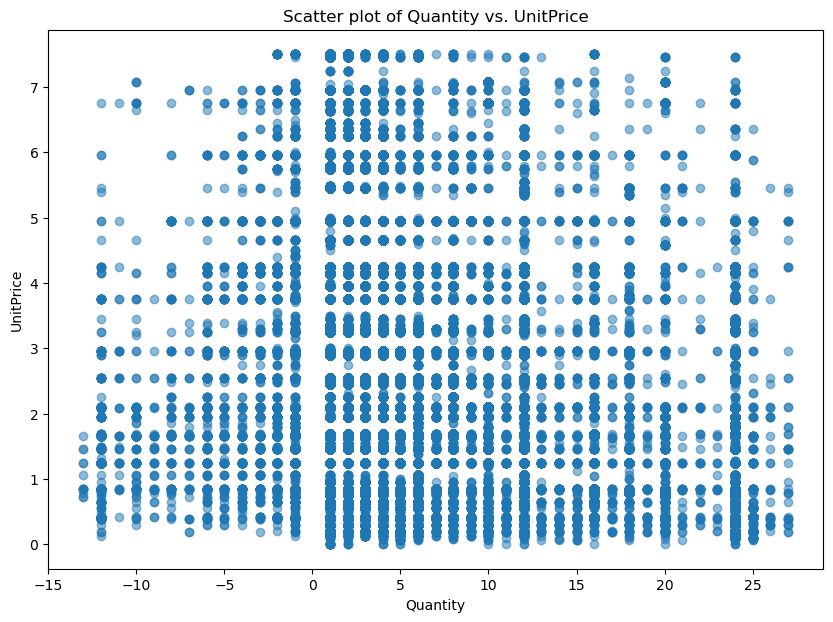

In [15]:
plt.figure(figsize=(10, 7))
plt.scatter(df_clean["Quantity"], df_clean["UnitPrice"], alpha=0.5)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Scatter plot of Quantity vs. UnitPrice")
plt.show()

#### Select the numeric columns to scale

In [16]:
numerical_columns = ["Quantity", "UnitPrice"]

#### Scale the data

In [17]:
scaler = StandardScaler()
df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])

C:\Users\hassa\AppData\Local\Temp\ipykernel_14860\3115133299.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[numerical_columns] = scaler.fit_transform(df_clean[numerical_columns])


In [18]:
df_clean

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,-0.185995,12/1/2010 8:26,0.225224,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,-0.185995,12/1/2010 8:26,0.767699,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,0.104668,12/1/2010 8:26,0.354385,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,-0.185995,12/1/2010 8:26,0.767699,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,-0.185995,12/1/2010 8:26,0.767699,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,0.685996,12/9/2011 12:50,-0.872643,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,-0.185995,12/9/2011 12:50,-0.065388,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,-0.476659,12/9/2011 12:50,1.258510,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,-0.476659,12/9/2011 12:50,1.258510,12680.0,France


#### Plot Quantity vs. UnitPrice

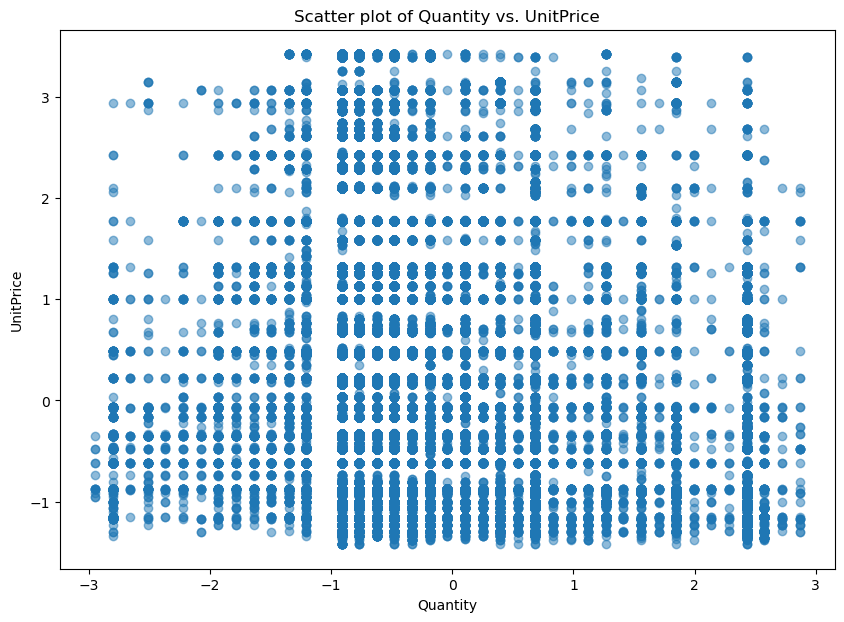

In [19]:
plt.figure(figsize=(10, 7))
plt.scatter(df_clean["Quantity"], df_clean["UnitPrice"], alpha=0.5)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Scatter plot of Quantity vs. UnitPrice")
plt.show()

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super

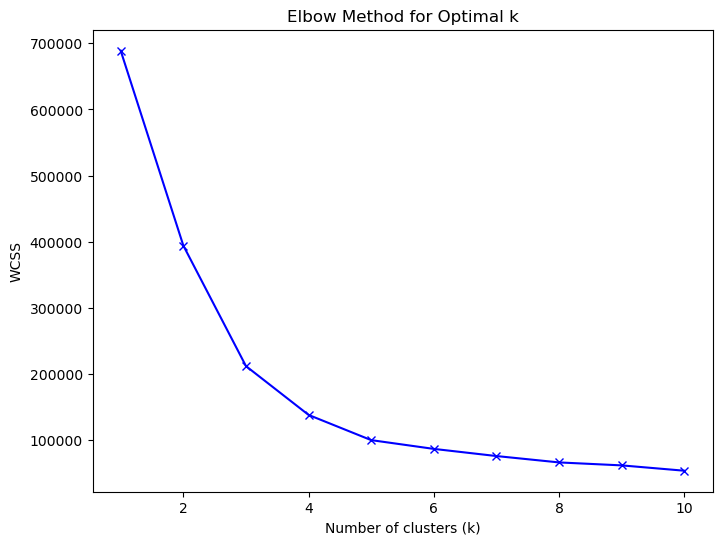

In [20]:
wcss = []
k_values = range(1, 11)  # Check from 1 to 10 clusters

# Calculate WCSS for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, max_iter=100, random_state=42)
    kmeans.fit(df_clean[numerical_columns])
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(k_values, wcss, 'bx-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.show()

#### Apply K-Means clustering with 4 clusters

In [21]:
kmeans = KMeans(n_clusters=4, max_iter=100, random_state=42)
kmeans.fit(df_clean[numerical_columns])

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(max_iter=100, n_clusters=4, random_state=42)

#### Assign clusters to the data

In [22]:
df_clean["Cluster"] = kmeans.labels_

C:\Users\hassa\AppData\Local\Temp\ipykernel_14860\4168703019.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["Cluster"] = kmeans.labels_


#### Visualize the clusters

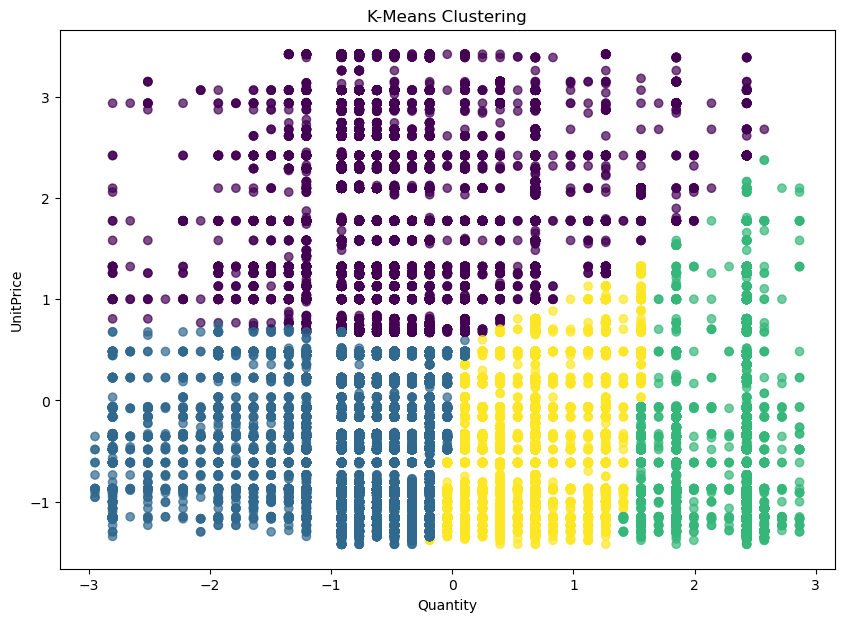

In [23]:
plt.figure(figsize=(10, 7))
plt.scatter(df_clean["Quantity"], df_clean["UnitPrice"], c=df_clean["Cluster"], cmap='viridis', alpha=0.7)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("K-Means Clustering")
plt.show()

#### Take a random sample (10% of the data) as RAM issue is occuring on whole dataset

In [24]:
sample_fraction = 0.10
df_subset = df_clean.sample(frac=sample_fraction, random_state=42)

#### Apply Agglomerative Clustering with 4 clusters and visualize the clusters

D:\Anaconda\Lib\site-packages\sklearn\cluster\_agglomerative.py:1005: FutureWarning: Attribute `affinity` was deprecated in version 1.2 and will be removed in 1.4. Use `metric` instead
  warnings.warn(


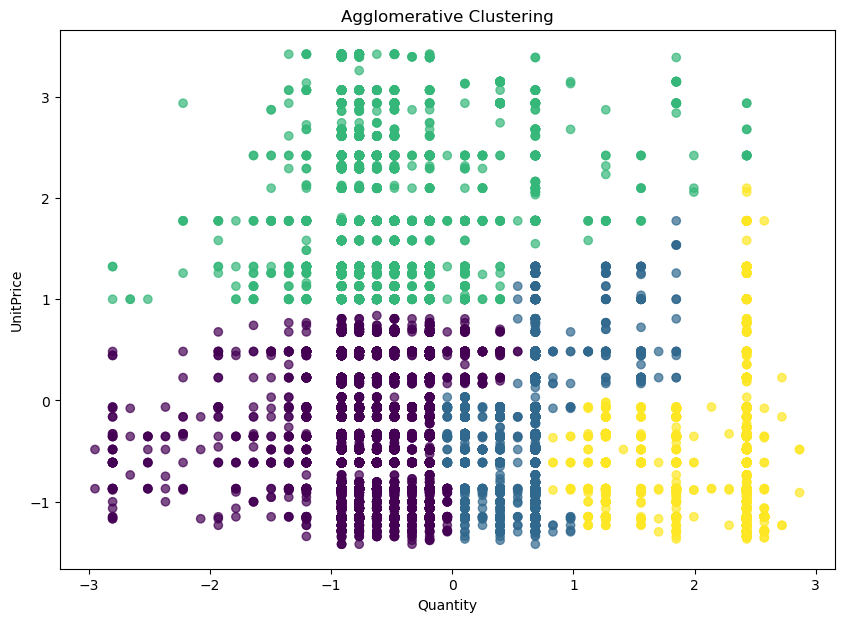

In [25]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering with 4 clusters
agg_clustering = AgglomerativeClustering(n_clusters=4, affinity='euclidean', linkage='ward')
df_subset["Cluster"] = agg_clustering.fit_predict(df_subset[numerical_columns])

# Visualize the clusters
plt.figure(figsize=(10, 7))
plt.scatter(df_subset["Quantity"], df_subset["UnitPrice"], c=df_subset["Cluster"], cmap='viridis', alpha=0.7)
plt.xlabel("Quantity")
plt.ylabel("UnitPrice")
plt.title("Agglomerative Clustering")
plt.show()